In [1]:
from src.graph import * 
from src.align import * 
from utils import * 
import networkx as nx
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
# Trying out assembly graph-based approach to resolving divergent strains. 

# (1) Read recruitment to generate a subset of reads to work from. 
# Start with a seed contig and run bbmap against a sample. 

In [3]:
align_df = align_filter('../data/test/alignments.tsv')
reads_df = pd.read_csv('../data/test/reads.csv', index_col=0)
read_ids = FASTAFile.from_file('../data/test/reads.fasta').ids
print('\nNum. mapped reads:', len(reads_df))
print('Num. aligned reads:', len(set(align_df['query'].unique().tolist() + align_df['target'].unique().tolist())))
print('Num. iterations:', reads_df.iteration.nunique())

align_filter: Loaded 24114 alignments from ../data/test/alignments.tsv
align_filter: 332 alignments failing filter opposite_strand_alignments
align_filter: 2276 alignments failing filter self_alignments
align_filter: 1520 alignments failing filter non_extreme_endpoints
align_filter: 4007 alignments failing filter duplicate_alignment_pairs
align_filter: 17592 alignments remaining after filtering

Num. mapped reads: 1499
Num. aligned reads: 1138
Num. iterations: 4


In [4]:
read_ids

array(['151.1.F', '24.0.F', '110.0.F', ..., '9.0.R', '9.1.F', '9.1.R'],
      shape=(2065,), dtype='<U7')

In [13]:

graph = StringGraph(align_path='../data/test/alignments.tsv', reads_path='../data/test/reads.fasta')

# fig, ax = plt.subplots()

# nx.draw(graph.T, ax=ax, node_size=1)

align_filter: Loaded 24114 alignments from ../data/test/alignments.tsv
align_filter: 332 alignments failing filter opposite_strand_alignments
align_filter: 2276 alignments failing filter self_alignments
align_filter: 1520 alignments failing filter non_extreme_endpoints
align_filter: 4007 alignments failing filter duplicate_alignment_pairs
align_filter: 17592 alignments remaining after filtering
StringGraph._remove_symmetric_edges: Removing 1066 symmetric edges.
StringGraph._remove_contained_reads: Removing 543 contained reads.
37


In [8]:
g = graph.G.subgraph(graph.strongly_connected_components[-1])

len(graph.strongly_connected_components)

1

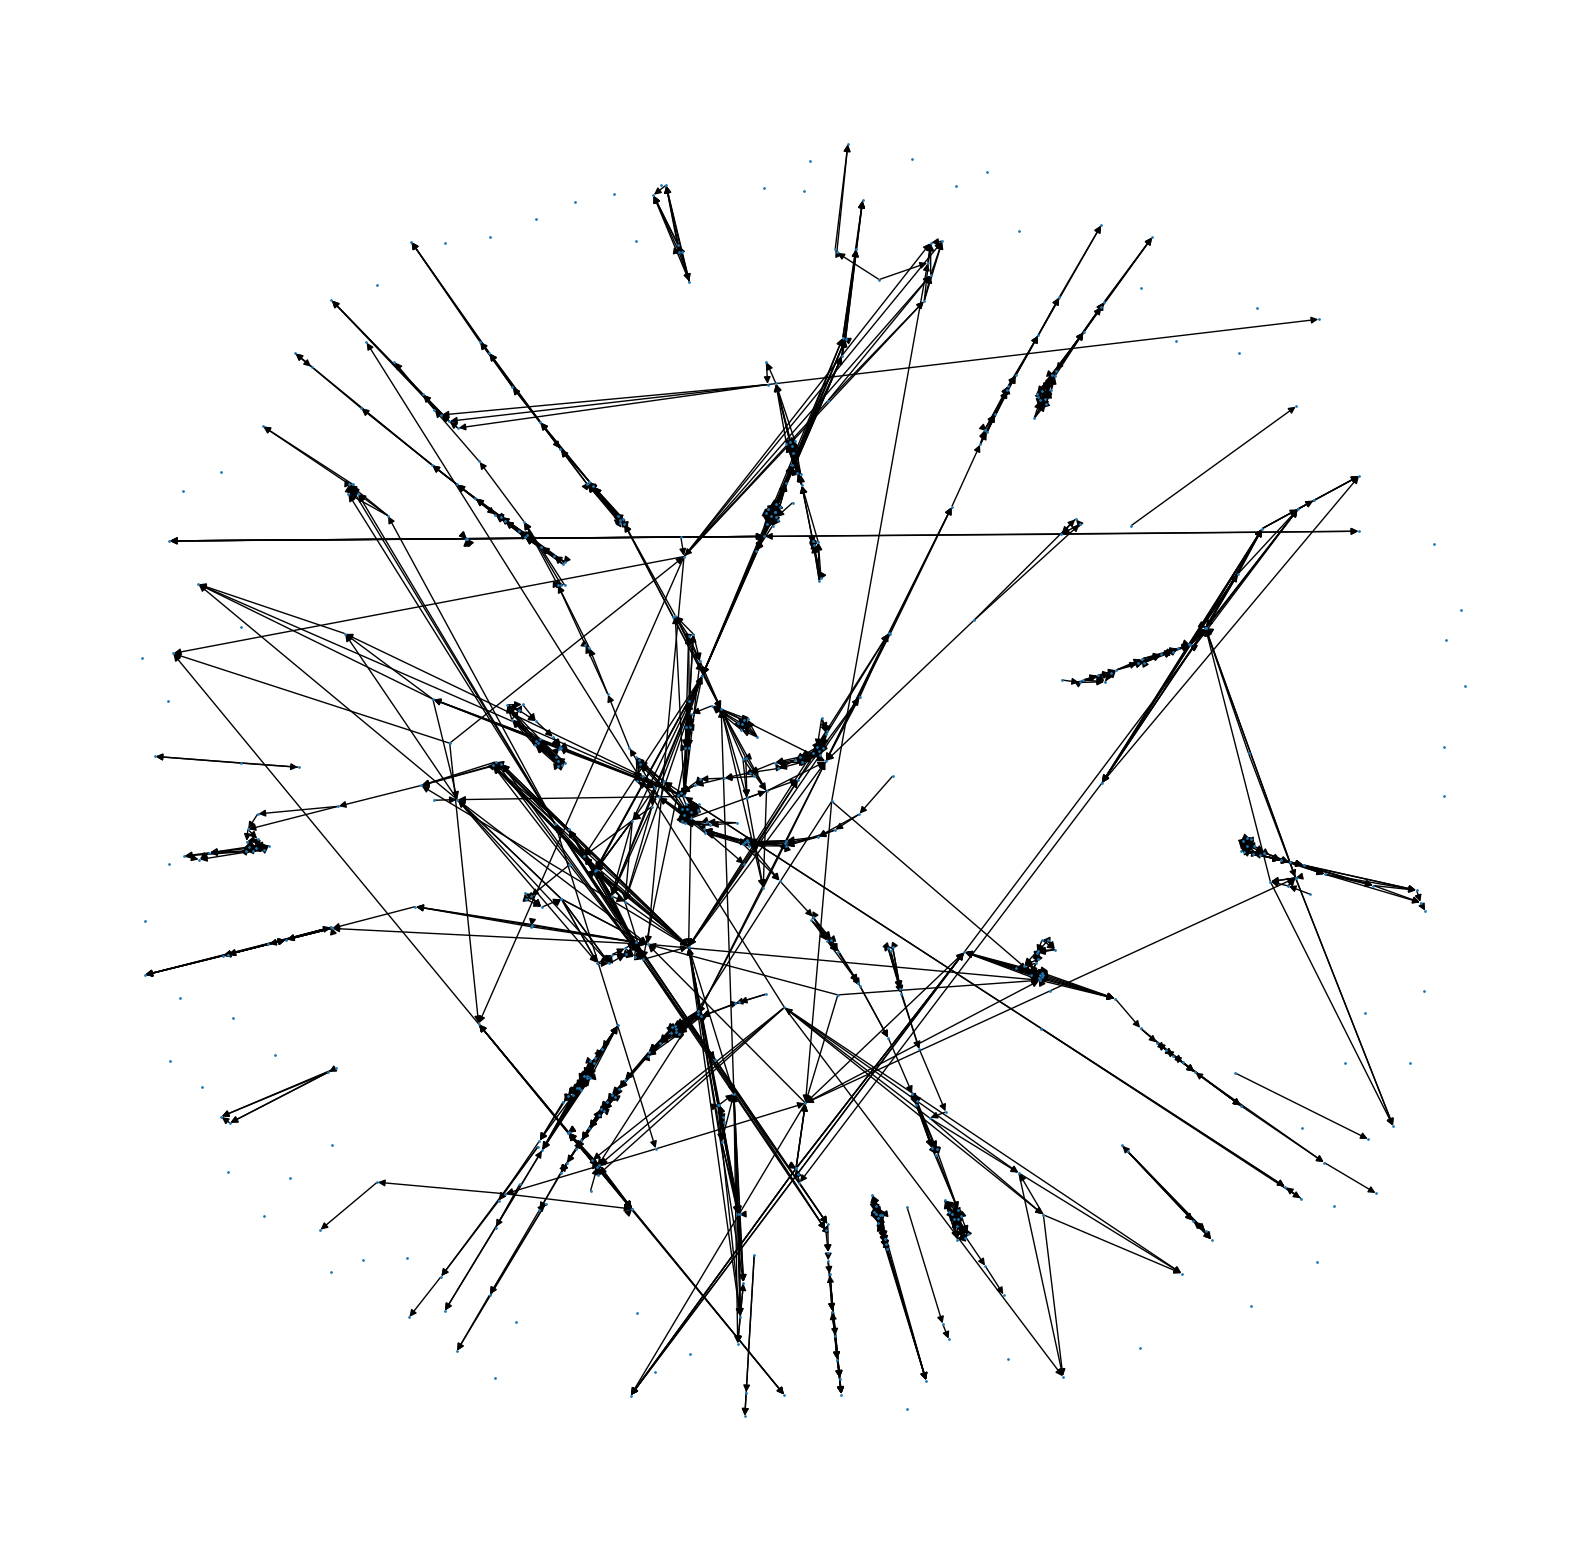

In [14]:
fig, ax = plt.subplots(figsize=(20, 20))
nx.draw(graph.G, ax=ax, node_size=1)